# Notebook 02: Gaussian Mixture Model (GMM)

In this notebook, we establish our baseline using a Gaussian Mixture Model on the continuous, PCA-reduced dataset. 

**Steps:**
1. Load the preprocessed PCA data.
2. Find the optimal number of components ($K$).
3. Train the final GMM.
4. Evaluate using clustering metrics (Purity, ARI, NMI).
5. Generate brand-new handwritten digits by sampling from the learned Gaussian distributions.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
from scipy.stats import mode
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, accuracy_score, confusion_matrix

# Load the data processed in Notebook 01
X_pca = np.load('data/X_pca.npy')
y = np.load('data/y_labels.npy')

# Load the PCA model to reverse-transform later
with open('data/pca_model.pkl', 'rb') as f:
    pca = pickle.load(f)

print(f"Loaded X_pca shape: {X_pca.shape}")
print(f"Loaded labels shape: {y.shape}")

Loaded X_pca shape: (70000, 50)
Loaded labels shape: (70000,)


### Step 1: Finding the Optimal Number of Components ($K$)

Instead of blindly guessing $K=10$ (for 10 digits), we test multiple values and calculate the **BIC score**. 

**Parameter Definitions:**
* **`n_components` ($K$)**: The number of distinct Gaussian clusters the model will try to find.
* **`BIC` (Bayesian Information Criterion)**: A mathematical penalty score. A lower BIC means the model fits the data well without becoming overly complex. We look for an "elbow" or the lowest point in the curve.

Calculating BIC scores...
K=5 fitted. BIC: 5473129
K=10 fitted. BIC: 4413905
K=15 fitted. BIC: 3940379
K=20 fitted. BIC: 3669177
K=25 fitted. BIC: 3479173


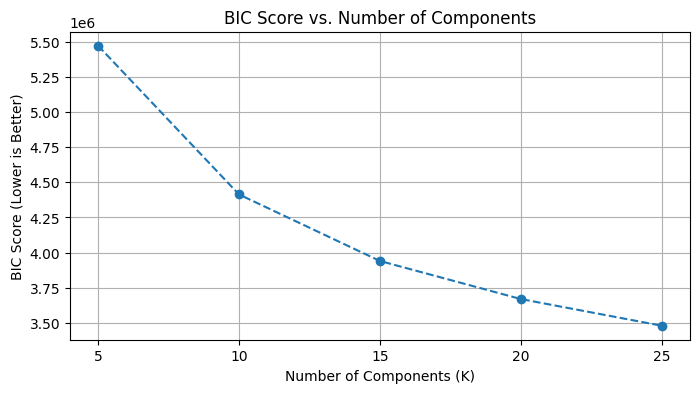

In [2]:
# Test a range of K values
k_values = [5, 10, 15, 20, 25]
bic_scores = []

print("Calculating BIC scores...")
for k in k_values:
    # Train a temporary GMM
    gmm_temp = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm_temp.fit(X_pca)
    bic_scores.append(gmm_temp.bic(X_pca))
    print(f"K={k} fitted. BIC: {bic_scores[-1]:.0f}")

# Plotting the BIC curve
plt.figure(figsize=(8, 4))
plt.plot(k_values, bic_scores, marker='o', linestyle='--')
plt.title("BIC Score vs. Number of Components")
plt.xlabel("Number of Components (K)")
plt.ylabel("BIC Score (Lower is Better)")
plt.xticks(k_values)
plt.grid(True)
plt.show()

### Step 2: Training

Based on the BIC curve we got above, we will set our final $K$ = 25. Using more than 10 components allows the model to capture different writing styles (e.g., crossed vs. uncrossed 7s, hat (1) vs without hat ones (l), etc.).


Training final GMM with K=25...
Converged at iteration 56
Training complete!


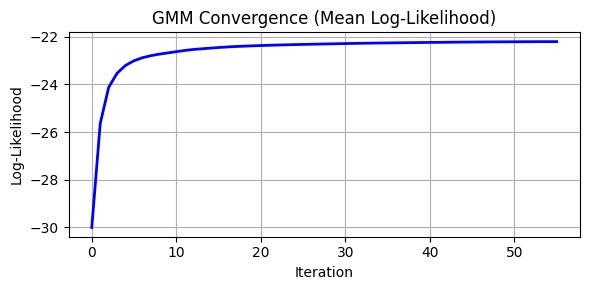

In [10]:
import warnings
from sklearn.exceptions import ConvergenceWarning

OPTIMAL_K = 25

# Initialize with warm_start=True to train it step-by-step
final_gmm = GaussianMixture(
    n_components=OPTIMAL_K, 
    covariance_type='full', 
    max_iter=1,          
    warm_start=True,     
    random_state=42
)

log_likelihood_history = []
max_epochs = 150
tolerance = 1e-3

print(f"Training final GMM with K={OPTIMAL_K}...")

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=ConvergenceWarning)
    
    for i in range(max_epochs):
        final_gmm.fit(X_pca)
        
        # scikit-learn stores the current log-likelihood in the 'lower_bound_' attribute
        current_ll = final_gmm.lower_bound_
        log_likelihood_history.append(current_ll)
        
        # Manually check for convergence
        if i > 0 and abs(current_ll - log_likelihood_history[-2]) < tolerance:
            print(f"Converged at iteration {i+1}")
            break

# Predict final cluster assignments
clusters = final_gmm.predict(X_pca)
print("Training complete!")

# Plot the Log-Likelihood curve
plt.figure(figsize=(6, 3))
plt.plot(log_likelihood_history, color='blue', linewidth=2)
plt.title("GMM Convergence (Mean Log-Likelihood)")
plt.xlabel("Iteration")
plt.ylabel("Log-Likelihood")
plt.grid(True)
plt.tight_layout()
plt.show()

### Step 3: Evaluation

We calculate three metrics to see how well our unsupervised clusters match the true labels:

* **Purity**: What percentage of images in a cluster belong to its most frequent true digit?

* **ARI (Adjusted Rand Index)**: Measures overlap between clusters and true labels, correcting for random chance (1.0 is perfect).

* **NMI (Normalized Mutual Information)**: Measures the shared information between predicted and true labels.

We also plot the confusion matrix to visually expose the model's blind spots.

--- GMM Evaluation Metrics (K=25) ---
Mapped Accuracy (Purity): 76.89%
ARI: 0.3592
NMI: 0.6206



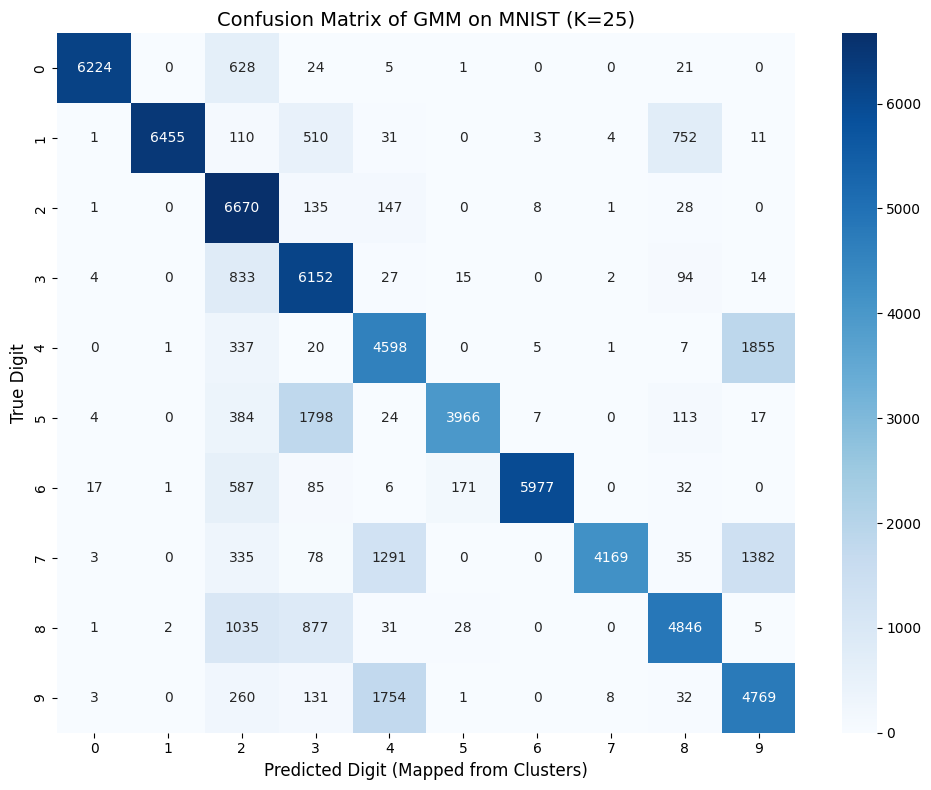

In [17]:
# 1. Unsupervised Metrics
ari = adjusted_rand_score(y, clusters)
nmi = normalized_mutual_info_score(y, clusters)

# 2. Mapping Function
def map_clusters_to_digits(y_true, y_pred, n_clusters):
    labels = np.zeros_like(y_pred)
    for cluster in range(n_clusters):
        mask = (y_pred == cluster)
        if np.any(mask):
            # Assign the most frequent true label in this cluster
            labels[mask] = mode(y_true[mask], keepdims=False).mode
    return labels

# Map the clusters to actual digits (0-9)
y_pred_mapped = map_clusters_to_digits(y, clusters, n_clusters=OPTIMAL_K)

# 3. Calculate Mapped Accuracy (Purity)
acc = accuracy_score(y, y_pred_mapped)

print(f"--- GMM Evaluation Metrics (K={OPTIMAL_K}) ---")
print(f"Mapped Accuracy (Purity): {acc * 100:.2f}%")
print(f"ARI: {ari:.4f}")
print(f"NMI: {nmi:.4f}\n")

# 4. Plot Confusion Matrix
cm = confusion_matrix(y, y_pred_mapped, labels=range(10))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Digit (Mapped from Clusters)', fontsize=12)
plt.ylabel('True Digit', fontsize=12)
plt.title(f'Confusion Matrix of GMM on MNIST (K={OPTIMAL_K})', fontsize=14)
plt.tight_layout()
plt.show()

# Save metrics for the final comparison notebook
gmm_metrics = {'Accuracy': acc, 'ARI': ari, 'NMI': nmi}
with open('data/gmm_metrics.pkl', 'wb') as f:
    pickle.dump(gmm_metrics, f)

### Step 4: Generating New Data

A major advantage of generative models is that we can sample from them. 
1. We ask the GMM to generate new points in the 50-dimensional PCA space.
2. We use `pca.inverse_transform` to convert them back into 784-dimensional pixel arrays.
3. We reshape them to $28 \times 28$ and plot!

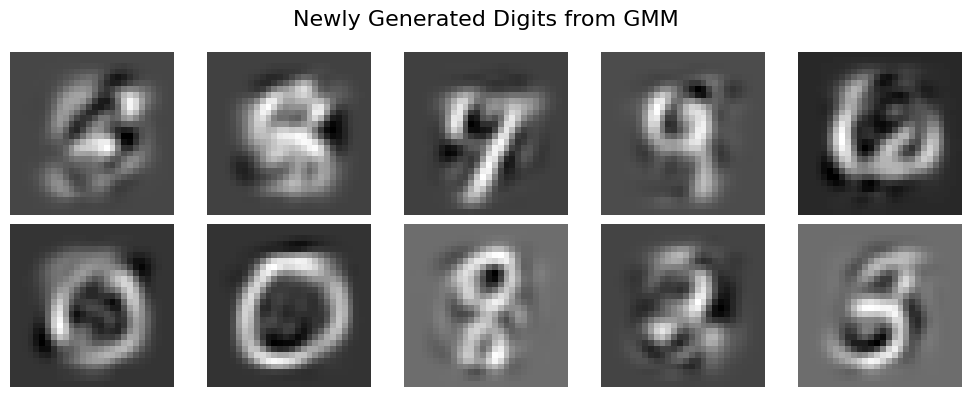

In [19]:
# 1. Sample 10 new data points from the learned Gaussian distribution
new_pca_samples, _ = final_gmm.sample(10)

# 2. Uncompress them from 50 dims back to 784 dims using PCA
generated_digits_flat = pca.inverse_transform(new_pca_samples)

# 3. Plot the generated digits
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle("Newly Generated Digits from GMM", fontsize=16)

for i, ax in enumerate(axes.flatten()):
    img = generated_digits_flat[i].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()

# Save the fully uncompressed 784-dimensional generated images
np.save('data/gmm_samples.npy', generated_digits_flat)